In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("results.csv")

In [3]:
result_list = []
for idx,(k,v) in enumerate(df.groupby("set_id")):
    v_unique = v.drop_duplicates(subset=["target_id"])
    if len(v_unique) != 2:
        continue
    result = [k] + v_unique.target_id.values.tolist() + v_unique.assay_ids.values.tolist() + v_unique.target_name.values.tolist()
    result += [v_unique.r2.values[0],v_unique.seq_similarity.values[0],v_unique.doc_id.values[0],v_unique.doi.values[0]]
    result_list.append(result)

In [4]:
cols = ["set_id","target_id_1","target_id_2","assay_id_1","assay_id_2","target_name_1","target_name_2","R2","seq_sim","doc_id","doi"]
result_df = pd.DataFrame(result_list,columns=cols).round(2)

In [5]:
result_df[["set_id","target_name_1","target_name_2","R2","seq_sim"]].sample(20)

,set_id,target_name_1,target_name_2,R2,seq_sim
4410,4411,Tyrosine-protein kinase JAK1,Tyrosine-protein kinase JAK3,0.77,0.38
918,919,Melatonin receptor type 1A,Melatonin receptor type 1B,0.72,0.59
3378,3379,Tyrosine-protein kinase Fer,Testis-specific serine/threonine-protein kinase 1,0.60,0.13
4400,4401,LIM domain kinase 1,LIM domain kinase 2,0.81,0.53
2127,2128,Tyrosine-protein phosphatase non-receptor type 1,Tyrosine-protein phosphatase non-receptor type 2,0.81,0.55
4529,4530,2-amino-4-hydroxy-6-hydroxymethyldihydropterid...,2-amino-4-hydroxy-6-hydroxymethyldihydropterid...,0.68,0.37
5401,5402,Melanocortin receptor 5,Melanocortin receptor 4,0.82,0.62
1291,1292,Muscarinic acetylcholine receptor M3,Muscarinic acetylcholine receptor M4,0.80,0.47
1832,1833,NUAK family SNF1-like kinase 2,"Phosphorylase b kinase gamma catalytic chain, ...",0.65,0.22
1702,1703,RAC-alpha serine/threonine-protein kinase,RAC-beta serine/threonine-protein kinase,0.81,0.81


Text(0, 0.5, 'Number of Papers with $R^2$ >= 0.6')

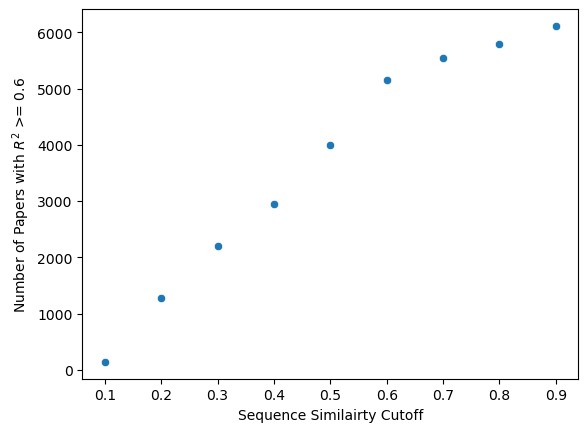

In [6]:
cutoff_res = []
for cutoff in np.arange(0.1,1,step=0.1):
    cutoff_res.append([cutoff,len(result_df.query("seq_sim <= @cutoff"))])
cutoff_df = pd.DataFrame(cutoff_res,columns=["seq_sim_cutoff","num_papers"])
ax = sns.scatterplot(x="seq_sim_cutoff",y="num_papers",data=cutoff_df)
ax.set_xlabel("Sequence Similairty Cutoff")
ax.set_ylabel("Number of Papers with $R^2$ >= 0.6")

In [7]:
result_df.sort_values("R2",ascending=False).head(25)

,set_id,target_id_1,target_id_2,assay_id_1,assay_id_2,target_name_1,target_name_2,R2,seq_sim,doc_id,doi
2423,2424,CHEMBL254,CHEMBL288,CHEMBL1805697,CHEMBL1805699,"3',5'-cyclic-AMP phosphodiesterase 4A","3',5'-cyclic-AMP phosphodiesterase 4D",1.00,0.61,CHEMBL1799977,10.1016/j.bmcl.2010.09.087
4497,4498,CHEMBL2424504,CHEMBL3774295,CHEMBL3788932,CHEMBL3788933,Lysine-specific demethylase 5A,Lysine-specific demethylase 5B,1.00,0.53,CHEMBL3784917,10.1021/acs.jmedchem.5b01758
1751,1752,CHEMBL3807,CHEMBL3521,CHEMBL1053999,CHEMBL1054000,Tyrosine-protein phosphatase non-receptor type 2,Receptor-type tyrosine-protein phosphatase F,1.00,0.00,CHEMBL1153002,10.1016/j.ejmech.2009.03.009
5855,5856,CHEMBL205,CHEMBL220,CHEMBL5265198,CHEMBL5265203,Carbonic anhydrase 2,Acetylcholinesterase,1.00,0.12,CHEMBL5260848,10.1016/j.ejmech.2020.112666
2022,2023,CHEMBL3729,CHEMBL2186,CHEMBL1074268,CHEMBL1074275,Carbonic anhydrase 4,Carbonic anhydrase 13,1.00,0.29,CHEMBL1157641,10.1016/j.bmc.2010.01.076
2033,2034,CHEMBL3242,CHEMBL2186,CHEMBL1074274,CHEMBL1074275,Carbonic anhydrase 12,Carbonic anhydrase 13,1.00,0.33,CHEMBL1157641,10.1016/j.bmc.2010.01.076
5854,5855,CHEMBL261,CHEMBL220,CHEMBL5265197,CHEMBL5265203,Carbonic anhydrase 1,Acetylcholinesterase,1.00,0.12,CHEMBL5260848,10.1016/j.ejmech.2020.112666
4366,4367,CHEMBL325,CHEMBL1937,CHEMBL3596003,CHEMBL3596004,Histone deacetylase 1,Histone deacetylase 2,1.00,0.85,CHEMBL3593208,10.1016/j.bmc.2015.03.063
3929,3930,CHEMBL253,CHEMBL2470,CHEMBL2383561,CHEMBL2383566,Cannabinoid receptor 2,Cannabinoid receptor 2,1.00,0.81,CHEMBL2380310,10.1021/jm400182t
4953,4954,CHEMBL4588,CHEMBL321,CHEMBL4193096,CHEMBL4193097,Neutrophil collagenase,Matrix metalloproteinase-9,1.00,0.30,CHEMBL4190296,10.1016/j.ejmech.2017.07.020


In [83]:
doc_df = df.query("doc_id == 'CHEMBL1131391'").copy()
cols = ['molregno','target_name','pchembl']
pivot_df = pd.pivot_table(doc_df[cols],values=['pchembl'],columns=['target_name'],index=["molregno"])
pivot_df.columns = pivot_df.columns.droplevel(0)
pivot_df.columns.name = None
pivot_df.columns = ["M1","M2","M3","M4","M5"]

In [111]:
result_df.query("doc_id == 'CHEMBL1131391'").drop_duplicates("set_id")

,set_id,target_id_1,target_id_2,assay_id_1,assay_id_2,target_name_1,target_name_2,R2,seq_sim,doc_id,doi
63,64,CHEMBL211,CHEMBL1821,CHEMBL747774,CHEMBL749766,Muscarinic acetylcholine receptor M2,Muscarinic acetylcholine receptor M4,0.64,0.59,CHEMBL1131391,10.1016/s0960-894x(98)00351-5
64,65,CHEMBL216,CHEMBL245,CHEMBL748282,CHEMBL745650,Muscarinic acetylcholine receptor M1,Muscarinic acetylcholine receptor M3,0.82,0.56,CHEMBL1131391,10.1016/s0960-894x(98)00351-5
65,66,CHEMBL216,CHEMBL2035,CHEMBL748282,CHEMBL748448,Muscarinic acetylcholine receptor M1,Muscarinic acetylcholine receptor M5,0.93,0.55,CHEMBL1131391,10.1016/s0960-894x(98)00351-5
66,67,CHEMBL245,CHEMBL1821,CHEMBL745650,CHEMBL749766,Muscarinic acetylcholine receptor M3,Muscarinic acetylcholine receptor M4,0.62,0.47,CHEMBL1131391,10.1016/s0960-894x(98)00351-5
67,68,CHEMBL245,CHEMBL2035,CHEMBL745650,CHEMBL748448,Muscarinic acetylcholine receptor M3,Muscarinic acetylcholine receptor M5,0.79,0.53,CHEMBL1131391,10.1016/s0960-894x(98)00351-5


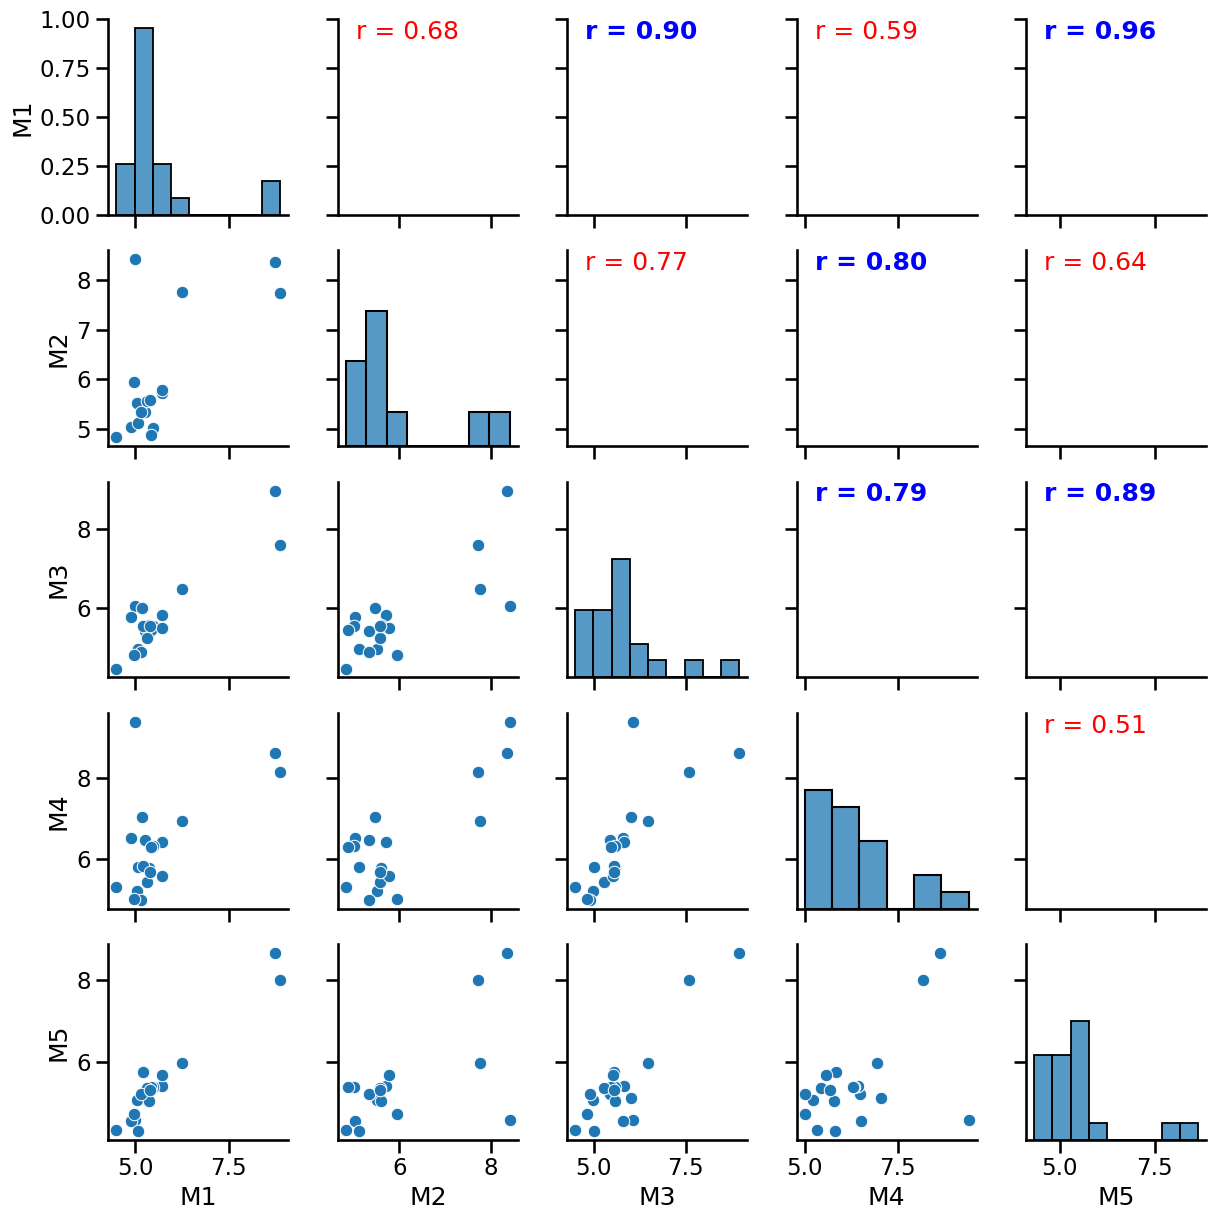

In [107]:
sns.set_context('talk')
def corrfunc(x, y, ax=None, **kws):
    # 1. Clean data: Remove rows where either x or y is NaN
    df_temp = pd.DataFrame({'x': x, 'y': y}).dropna()
    
    # 2. Safety check for insufficient data or zero variation
    if len(df_temp) < 2 or df_temp['x'].std() == 0 or df_temp['y'].std() == 0:
        r_text = "N/A"
        text_color = "black"
        is_bold = "normal"
    else:
        # 3. Calculate Pearson r
        r, _ = pearsonr(df_temp['x'], df_temp['y'])
        r_text = f'r = {r:.2f}'
        
        # 4. Logic: Blue and Bold if >= 0.77, else Red and Normal
        if r >= 0.77:
            text_color = "blue"
            is_bold = "bold"
        else:
            text_color = "red"
            is_bold = "normal"

    # 5. Annotate the plot
    ax = ax or plt.gca()
    ax.annotate(r_text, 
                xy=(.1, .9), 
                xycoords=ax.transAxes, 
                color=text_color, 
                fontweight=is_bold)
        
# 2. Initialize the Grid
g = sns.PairGrid(pivot_df)

# 3. Map different functions to sections
g.map_diag(sns.histplot)      # Diagonals (e.g., histograms)
g.map_lower(sns.scatterplot)  # Lower triangle (e.g., scatter plots)
g.map_upper(corrfunc)         # Upper triangle (your Pearson r function)


27937
94171
94226
94227
94259
94260
94300
94330
94331
94358
94365
94416
94448
94449
94521
94561
94562
150389


Text(0, 0.5, 'pIC$_{50}$ Muscarinic acetylcholine receptor M4')

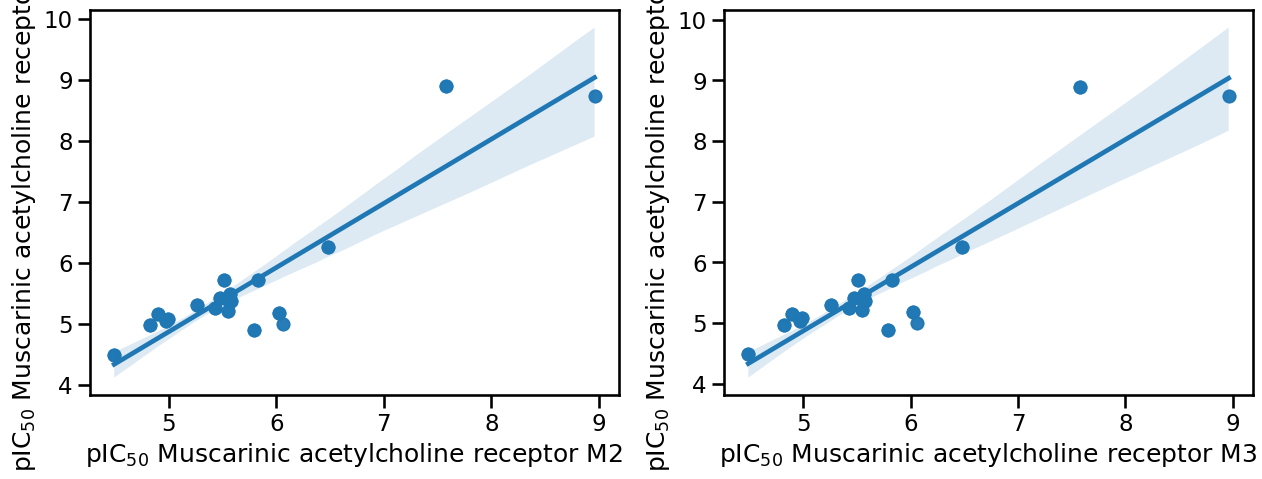

In [102]:
figure, axes = plt.subplots(1,2,figsize=(15,5))
assays = ["CHEMBL747774","CHEMBL749766"]
for k,v in df.query("set_id == 65 and assay_ids in @assays").groupby("molregno"):
    act_list.append(v.sort_values("assay_ids").pchembl.values)
act_df_1 = pd.DataFrame(act_list,columns=assays)
target_1 = df.query("assay_ids == @assays[0]").target_name.values[0]
target_2 = df.query("assay_ids == @assays[1]").target_name.values[0]
ax = sns.regplot(x=assays[0],y=assays[1],data=act_df_1,ax=axes[0])
ax.set_xlabel("pIC$_{50}$ " + target_1)
ax.set_ylabel("pIC$_{50}$ " + target_2)


assays = ["CHEMBL745650","CHEMBL749766"]
for k,v in df.query("set_id == 65 and assay_ids in @assays").groupby("molregno"):
    print(k)
    act_list.append(v.sort_values("assay_ids").pchembl.values)
act_df_2 = pd.DataFrame(act_list,columns=assays)
target_1 = df.query("assay_ids == @assays[0]").target_name.values[0]
target_2 = df.query("assay_ids == @assays[1]").target_name.values[0]
ax = sns.regplot(x=assays[0],y=assays[1],data=act_df_2,ax=axes[1])
ax.set_xlabel("pIC$_{50}$ " + target_1)
ax.set_ylabel("pIC$_{50}$ " + target_2)

In [43]:
act_df_1,act_df_2

(     CHEMBL747774  CHEMBL749766
 0            6.06          5.00
 1            6.48          6.26
 2            6.02          5.18
 3            4.97          5.04
 4            5.79          4.89
 ..            ...           ...
 287          5.51           NaN
 288          4.90           NaN
 289          5.55           NaN
 290          4.82           NaN
 291          7.58           NaN
 
 [292 rows x 2 columns],
      CHEMBL745650  CHEMBL749766
 0            6.06          5.00
 1            6.48          6.26
 2            6.02          5.18
 3            4.97          5.04
 4            5.79          4.89
 ..            ...           ...
 305          5.51           NaN
 306          4.90           NaN
 307          5.55           NaN
 308          4.82           NaN
 309          7.58           NaN
 
 [310 rows x 2 columns])

In [14]:
assays = ["CHEMBL748282","CHEMBL745650"]
#result_df = df.query("set_id == 65 and assay_ids in @assays").assay_ids.value_counts()
for k,v in df.query("set_id == 65 and assay_ids in @assays").groupby("molregno"):
    act_list.append(v.sort_values("assay_ids").pchembl.values)
act_df = pd.DataFrame(act_list,columns=assays)
target_1 = df.query("assay_ids == @assays[0]").target_name.values[0]
target_2 = df.query("assay_ids == @assays[1]").target_name.values[0]

In [15]:
out_df = act_df.copy()
out_df.columns = ["pIC$_{50}$ " + target_1, "pIC$_{50}$ " + target_2]
out_df.to_csv("muscarinic.csv")

Text(0, 0.5, 'pIC$_{50}$ Muscarinic acetylcholine receptor M3')

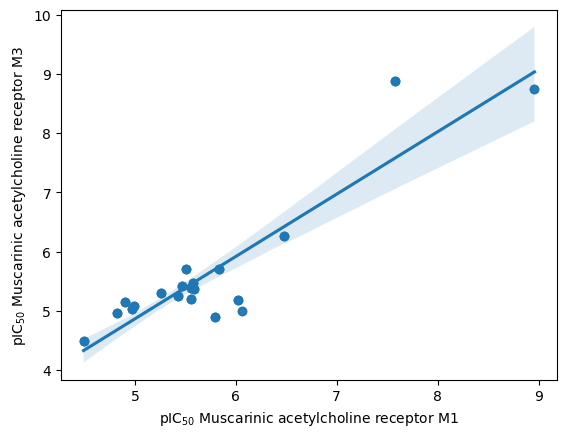

In [16]:
ax = sns.regplot(x=assays[0],y=assays[1],data=act_df)
ax.set_xlabel("pIC$_{50}$ " + target_1)
ax.set_ylabel("pIC$_{50}$ " + target_2)

In [119]:
df.query("set_id == 65").doi.values[0]

'10.1016/s0960-894x(98)00351-5'

In [120]:
len(act_df)

20

In [126]:
pearsonr(act_df.values[:,0],act_df.values[:,1])[0]**2

np.float64(0.8184193068430347)

In [133]:
df.query("set_id == 65")

,set_id,canonical_smiles,molregno,target_id,target_name,pchembl,seq_similarity,r2,doc_id,doi,assay_ids
1844,65,CCOC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2ccc(OC)cc...,94226,CHEMBL216,Muscarinic acetylcholine receptor M1,5.04,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL748282
1845,65,CCOC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2ccc(OC)cc...,94226,CHEMBL245,Muscarinic acetylcholine receptor M3,4.97,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL745650
1846,65,CCOC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2cc(OC)c(O...,94227,CHEMBL216,Muscarinic acetylcholine receptor M1,4.89,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL748282
1847,65,CCOC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2cc(OC)c(O...,94227,CHEMBL245,Muscarinic acetylcholine receptor M3,5.79,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL745650
1848,65,COC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2cc(OC)ccc2...,94358,CHEMBL216,Muscarinic acetylcholine receptor M1,5.42,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL748282
1849,65,COC(=O)c1c(C)[nH]c2ccc3c(c12)CN1CCc2cc(OC)ccc2...,94358,CHEMBL245,Muscarinic acetylcholine receptor M3,5.47,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL745650
1850,65,COc1cc2c(cc1OC)C1Oc3ccc4[nH]c(C)cc4c3CN1CC2,94365,CHEMBL216,Muscarinic acetylcholine receptor M1,4.49,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL748282
1851,65,COc1cc2c(cc1OC)C1Oc3ccc4[nH]c(C)cc4c3CN1CC2,94365,CHEMBL245,Muscarinic acetylcholine receptor M3,4.49,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL745650
1852,65,C[C@@H]1OC(=O)[C@H]2C[C@H]3CCCC[C@@H]3[C@@H](/...,27937,CHEMBL216,Muscarinic acetylcholine receptor M1,6.26,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL748282
1853,65,C[C@@H]1OC(=O)[C@H]2C[C@H]3CCCC[C@@H]3[C@@H](/...,27937,CHEMBL245,Muscarinic acetylcholine receptor M3,6.48,0.556087,0.818419,CHEMBL1131391,10.1016/s0960-894x(98)00351-5,CHEMBL745650
